# **4.1 Multi-layer Perceptron**
In Chapter 3, we introduced softmax regression ([Section 3.4](../../chapter_linear_neural_network/content/softmax_regression.ipynb#34)), then implemented it from scratch ([Section 3.6](../../chapter_linear_neural_network/content/implementing_softmax_regression_from_scratch.ipynb#36)), followed by implementing the algorithm using a high-level API ([Section 3.7](../../chapter_linear_neural_network/content/concise_implementation_of_softmax_regression.ipynb#37)), and trained a classifier to recognize 10 categories of clothing from low-resolution images. Throughout this process, we learned how to process data, how to transform outputs into valid probability distributions, and how to apply appropriate loss functions to minimize the loss based on the model parameters. We have already mastered this knowledge in the context of simple linear models, and now we can begin exploring deep neural networks, which are the primarytype of model covered in this book.

## **4.1.1 Hidden Layer**
In [Section 3.1.1](../chapter_linear_neural_network/content/linear_regression.ipynb/#311), we described the affine transformation, which is a linear transformation with a bias term. First, let’s recall the model architecture of softmax regression, as shown in [Figure 3.4.1](../../chapter_linear_neural_network/content/softmax_regression.ipynb#fig341). This model maps our input directly to the output via a single affine transformation, followed by a softmax operation. If our labels are indeed correlated with our input data after passing through the affine transformation, then this approach is sufficient. However, **the linearity of the affine transformation is a strong assumption**.

### **Linear models may produce errors**
For example, **linearity implies a monotonicity assumption: an increase in any feature will lead to an increase in the model’s output (if the corresponding weight is positive) or a decrease in the model’s output (if the corresponding weight is negative).** Sometimes this makes sense. For example, if we are trying to predict whether a person will repay a loan. We might assume that, all other things being equal, applicants with higher incomes are more likely to repay the loan than those with lower incomes. However, while there is a monotonic relationship between income and the probability of repayment, they are not linearly correlated. An increase in income from 0 to 50,000 may result in a greater likelihood of repayment than an increase from 1,000,000 to 1,050,000. One way to address this issue is to preprocess our data to make linearity more reasonable, such as by using the logarithm of income as our feature.<br><br>
However, it is easy to find examples that violate monotonicity. For example, suppose we want to predict mortality based on body temperature. For people with a body temperature above 37 degrees Celsius, the higher the temperature, the greater the risk. However, for people with a body temperature below 37 degrees Celsius, the higher the temperature, the lower the risk. In this case, we can also solve the problem through some clever preprocessing. For example, we can use the distance from 37 degrees Celsius as a feature.<br><br>
But how do we classify images of cats and dogs? Does increasing the intensity of the pixel at position (13,17) always increase (or decrease) the likelihood that the image depicts a dog? **Relying on a linear model corresponds to an implicit assumption that the only requirement for distinguishing between cats and dogs is to evaluate the intensity of individual pixels. In a world where categories remain preserved even after an image is inverted, this approach is bound to fail.**<br><br>
Compared to our previous example, the linearity here is absurd, and it is difficult to resolve this issue through simple preprocessing. **This is because the importance of any given pixel depends in a complex way on its context (the values of the surrounding pixels).** Our data may have a representation that accounts for the interdependent interactions among features. Building a linear model based on this representation might be appropriate, but we do not know how to manually compute such a representation. For deep neural networks, we use observed data to jointly learn the hidden-layer representation and the
linear predictor applied to that representation.

### **Add a hidden layer to the network**
We can overcome the limitations of linear models by adding one or more hidden layers to the network, enabling it to handle more general types of functional relationships. **The simplest way to achieve this is to stack many fully connected layers on top of each other. Each layer feeds its output to the layer above it, until the final output is generated.** We can view the first L−1 layers as a representation and the final layer as a linear predictor. This architecture is commonly referred to as a multilayer
perceptron, typically abbreviated as MLP. Below, we illustrate the multilayer perceptron in a diagram [(Figure 4.1.1)](#fig411).
##### **Fig(4.1.1)**
![MLP](../../images/picture4_1_1.png)<br><br>
This multilayer perceptron has 4 inputs and 3 outputs, and its hidden layer contains 5 hidden units. The input layer does not involve any computations, so generating an output using this network requires only implementing the computations in the hidden layer and the output layer. Therefore, this multilayer perceptron has 2 layers. **Note that both layers are fully connected. Each input affects every neuron in the hidden layer, and every neuron in the hidden layer affects every neuron in the output layer.**

### **From Linear to Nonlinear**
As in previous sections, we use a matrix $X \in \mathbb{R}^{n × d}$ to represent a mini-batch of n samples, where each sample has $d$ input features. For a single-hidden-layer multi-layer perceptron with $h$ hidden units, the output of the hidden layer, denoted by $H \in \mathbb{R}^{n×h}$, is referred to as the hidden representations. In mathematics or code, H is also referred to as a hidden-layer variable or hidden variable (hidden variable). Since both the hidden layer and the output layer are fully connected, we have hidden layer weights $W(1) \in \mathbb{R}^{d \times h}$ and hidden layer biases $b(1) \in \mathbb{R}^{1 \times h}$, as well as output layer weights $W(2) \in \mathbb{R}^{h \times q}$ and output layer biases $b(2) \in \mathbb{R}^{1 \times q}$. Formally, we compute the output $O \in \mathbb{R}^{n \times q}$ of a single-hidden-layer multi-layer perceptron as follows:
##### **(4.1.1)**
$$
\begin{align}
H &= XW^{(1)} + b^{(1)} \\
O &= HW^{(2)} + b^{(2)}
\end{align}
$$
Note that after adding a hidden layer, the model now needs to track and update additional parameters. But what benefits do we gain from this? In the model defined above, we gain no benefits! **The reason is simple: the hidden units above are given by affine functions of the input, and the output (before the softmax operation) is simply an affine function of the hidden units. An affine function of an affine function is itself an affine function, but our previous linear model was already capable of representing any affine function.**<br><br>
We can prove this equivalence: for any weight values, we need only merge the hidden layers to produce an equivalent single-layer model with parameters $W = W^{(1)}W^{(2)}$ and $b = b^{(1)}W^{(2)} + b^{(2)}$:
##### **(4.1.2)**
$$O = (XW^{(1)} + b^{(1)})W^{(2)} + b^{(2)} = XW^{(1)}W^{(2)} + b^{(1)}W^{(2)}+ b^{(2)} = XW + B$$
To realize the full potential of a multilayer architecture, we need one additional key element: **applying a nonlinear activation function $\sigma$ to each hidden unit after the affine transformation. The output of the activation function (e.g., $\sigma$(·)) is referred to as an activation. Generally speaking, with an activation function, it is no longer possible to reduce our multilayer perceptron to a linear model**:
##### **(4.1.3)**
$$
\begin{align}
H &= \sigma(XW^{(1)} + b^{(1)}) \\
O &= HW^{(2)} + b^{(2)}
\end{align}
$$
Since each row in X corresponds to a sample in a mini-batch, for notational convenience, we define the nonlinear function σ to act on its input row-wise, that is, one sample at a time. In [Section 3.4.5](../../chapter_linear_neural_network/content/softmax_regression.ipynb#345), we used the softmax notation in the same way to denote row-wise operations. However, the activation functions applied to hidden layers in this section typically operate not only row-wise but also element-wise. This means that after computing the linear portion of each layer, we can compute each activation value without needing to examine the values taken by other hidden units. This is the case for most activation functions.<br><br>
To build a more general multi-layer perceptron, we can continue to stack such hidden layers—for example, $H^{(1)} = \sigma_{1}(XW^{(1)} + b^{(1)})$ and $H^{(2)} = \sigma_{2}(H^{(1)}W^{(2)} + b^{(2)})$—one layer on top of another, thereby creating a more expressive model.

### **General Approximation Theorem**
Multilayer perceptrons can capture complex interactions among inputs through hidden neurons, which depend on the values of each input. We can easily design hidden nodes to perform arbitrary computations. For example, by performing basic logical operations on a pair of inputs, multilayer perceptrons serve as general-purpose approximators. Even if a network has only one hidden layer, given enough neurons and the correct weights, we can model any function—though in practice, learning that function is difficult. Neural networks are somewhat like the C programming language. Like any other modern programming language, C is capable of expressing any computable program. But in reality, coming up with a program that meets the specifications is the hardest part.<br><br>
Furthermore, although a single-hidden-layer network can learn any function, this does not mean we should try to use such networks to solve all problems. **In fact, by using deeper (rather than wider) networks, we can more easily approximate many functions.** We will discuss this in greater detail in later chapters.

## **4.1.2 Activation Function**
**Activation functions determine whether a neuron should be activated by calculating a weighted sum and adding a bias; they are differentiable operations that convert input signals into outputs.** Most activation functions are nonlinear. Since activation functions form the foundation of deep learning, the following is a brief introduction to some common activation functions.

In [1]:
%matplotlib inline
import torch
from d2l import torch as d2l

### **ReLU Function**
The most popular activation function is the Rectified Linear Unit (ReLU), because **it is simple to implement and performs well across a variety of prediction tasks. ReLU provides a very simple nonlinear transformation. Given an element x, the ReLU function is defined as the maximum of that element and 0**:
##### **(4.1.4)**
$$ReLU(x)=max(x,0)$$
**Simply put, the ReLU function retains only the positive elements and discards all negative elements by setting the corresponding activation values to 0.** To get a better visual understanding, we can plot the function’s graph. As shown in the figure, the activation function is piecewise linear.

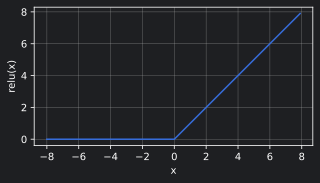

In [2]:
x = torch.arange(-8.0, 8.0, 0.1, requires_grad=True)
y = torch.relu(x)
d2l.plot(x.detach(), y.detach(), 'x', 'relu(x)', figsize=(5, 2.5))

**When the input is negative, the derivative of the ReLU function is 0, and when the input is positive, the derivative of the ReLU function is 1. Note that when the input value is exactly 0, the ReLU function is not differentiable. In this case, we default to using the left-hand side derivative, meaning that when the input is 0, the derivative is 0. We can ignore this case because the input will likely never be 0.**

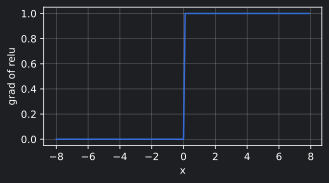

In [3]:
y.backward(torch.ones_like(x), retain_graph=True)
d2l.plot(x.detach(), x.grad, 'x', 'grad of relu', figsize=(5, 2.5))

**The reason for using ReLU is that it performs exceptionally well when differentiated: it either causes the parameter to vanish or allows it to pass through. This improves optimization performance, and ReLU alleviates the vanishing gradient problem that has plagued neural networks in the past.**<br><br>
Note that there are many variants of the ReLU function, including the parameterized ReLU (pReLU) function (Heetal., 2015). This variant adds a linear term to ReLU, so even if the parameters are negative, some information is still preserved:
##### **(4.1.5)**
$$pReLU(x) = max(0, x) + \alpha min(0,x)$$

### **Sigmoid Function**
For an input with a domain in $\mathbb{R}$, the sigmoid function maps the input to an output in the interval (0, 1). Therefore, the sigmoid is often referred to as a squashing function: it compresses any input in the range (‐inf, inf) to a value in the interval (0, 1):
##### **(4.1.6)**
$$sigmoid(x)=\frac{1}{1 + exp(-x)}$$
As interest in gradient-based learning grew, the sigmoid function emerged as a natural choice because **it is a smooth, differentiable approximation of a threshold cell. When we want to interpret the output as a probability in a binary classification problem, the sigmoid is still widely used as the activation function in the output layer (the sigmoid can be viewed as a special case of the softmax function).** However, the sigmoid is now rarely used in hidden layers; it has largely been replaced by the simpler,
easier-to-train ReLU.<br><br>
Next, we will plot the sigmoid function. **Note that when the input approaches 0, the sigmoid function behaves almost like a linear transformation.**

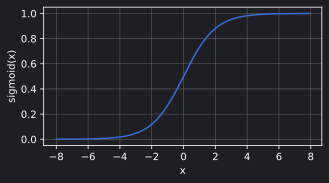

In [4]:
y = torch.sigmoid(x)
d2l.plot(x.detach(), y.detach(), 'x', 'sigmoid(x)', figsize=(5, 2.5))

The derivative of the sigmoid function is given by the following formula:
##### **(4.1.7)**
$$\frac{d}{dx}sigmoid(x)=\frac{exp(-x)}{(1+exp(-x))^{2}}=sigmoid(x)(1-sigmoid(x))$$
The graph of the derivative of the sigmoid function is shown below. Note that **when the input is 0, the derivative of the sigmoid function reaches a maximum value of 0.25; as the input moves further away from 0 in either direction, the derivative approaches 0.**

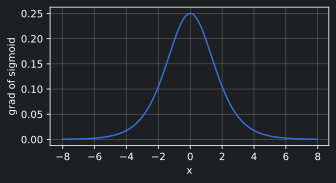

In [5]:
# Clear the previous gradient
x.grad.data.zero_()
y.backward(torch.ones_like(x), retain_graph=True)
d2l.plot(x.detach(), x.grad, 'x', 'grad of sigmoid', figsize=(5, 2.5))

### **tanh Function**
Similar to the sigmoid function, the tanh (hyperbolic tangent) function also maps its input to the interval (‐1, 1). The formula for the tanh function is as follows:
##### **(4.1.8)**
$$tanh(x)=\frac{1-exp(-2x)}{1+exp(-2x)}$$
Next, we'll plot the tanh function. Note that **when the input is near 0, the tanh function behaves almost like a linear transformation. The shape of the function is similar to that of the sigmoid function, except that the tanh function is symmetric about the origin of the coordinate system.**

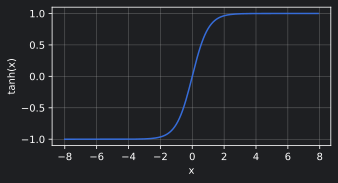

In [6]:
y = torch.tanh(x)
d2l.plot(x.detach(), y.detach(), 'x', 'tanh(x)', figsize=(5, 2.5))

The derivative of the tanh function is:
##### **(4.1.9)**
$$\frac{d}{dx}tanh(x)=1-tanh^{2}(x)$$
The graph of the derivative of the tanh function is shown below. **When the input approaches 0, the derivative of the tanh function approaches its maximum value of 1. Similar to what we saw in the graph of the sigmoid function, the further the input moves away from 0 in either direction, the closer the derivative approaches 0.**

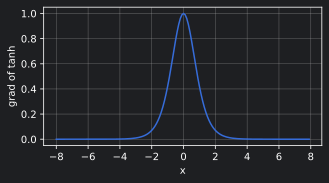

In [7]:
# Clear the previous gradient
x.grad.data.zero_()
y.backward(torch.ones_like(x), retain_graph=True)
d2l.plot(x.detach(), x.grad, 'x', 'grad of tanh', figsize=(5, 2.5))

## **Summary**
* A multilayer perceptron adds one or more fully connected hidden layers between the output layer and the input layer, and transforms the output of the hidden layers using activation functions.
* Commonly used activation functions include the ReLU function, the sigmoid function, and the tanh function.